In [17]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from scipy.signal import find_peaks, welch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [5]:
import sys
sys.path.append("..")
from UCI.pre_processing import  load_UCI_dataset

In [6]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(WINDOW_SIZE= 1000, STEP_SIZE= 500)

Total recordings: 12000
Train recordings: 8640
Validation recordings: 960
Test recordings: 2400


100%|██████████| 8640/8640 [01:36<00:00, 89.57it/s] 


Skipped recordings: 4


100%|██████████| 960/960 [00:10<00:00, 87.40it/s] 


Skipped recordings: 0


100%|██████████| 2400/2400 [00:27<00:00, 86.68it/s] 


Skipped recordings: 1


In [7]:
X_train = X_train.numpy()
X_val = X_val.numpy()
X_test = X_test.numpy()

y_train = y_train.numpy()
y_val = y_val.numpy()
y_test = y_test.numpy()

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (468372, 1, 1000), y_train shape: (468372, 2)


## Feature Exraction ##

In [8]:
from scipy.stats import skew, kurtosis
from scipy.signal import welch

In [9]:
def extract_ppg_features(ppg):

    return {
        "mean": np.mean(ppg),
        "std": np.std(ppg),
        "skewness": skew(ppg),
        "kurtosis": kurtosis(ppg),
        "rms": np.sqrt(np.mean(ppg ** 2)),
        "max": np.max(ppg),
        "min": np.min(ppg),
        "range": np.ptp(ppg)
    }

In [10]:
def extract_peak_features(ppg, fs=125):

    peaks, _ = find_peaks(
        ppg,
        distance=50,
        prominence=0.1 * np.std(ppg)
    )

    if len(peaks) < 2:

        return {
            "heart_rate": np.nan,
            "mean_peak_amplitude": np.nan,
            "std_peak_amplitude": np.nan,
            "mean_peak_distance": np.nan
        }

    peak_amplitudes = ppg[peaks]

    peak_distances = np.diff(peaks) / fs

    mean_peak_distance = np.mean(
        peak_distances
    )

    heart_rate = 60 / mean_peak_distance

    return {
        "heart_rate": heart_rate,
        "mean_peak_amplitude": np.mean(
            peak_amplitudes
        ),
        "std_peak_amplitude": np.std(
            peak_amplitudes
        ),
        "mean_peak_distance": mean_peak_distance
    }

In [11]:
def extract_vpg_apg_features(ppg, fs=125):

    vpg = np.gradient(ppg) * fs

    apg = np.gradient(vpg) * fs

    features = {

        "max_vpg": np.max(vpg),
        "min_vpg": np.min(vpg),
        "mean_vpg": np.mean(vpg),
        "std_vpg": np.std(vpg),

        "max_apg": np.max(apg),
        "min_apg": np.min(apg),
        "mean_apg": np.mean(apg),
        "std_apg": np.std(apg)
    }

    return features

In [12]:
def extract_frequency_features(ppg, fs=125):

    frequencies, power = welch(
        ppg,
        fs=fs,
        nperseg=min(256, len(ppg))
    )

    valid = frequencies > 0

    frequencies = frequencies[valid]
    power = power[valid]

    dominant_frequency = frequencies[
        np.argmax(power)
    ]

    spectral_energy = np.trapz(
        power,
        frequencies
    )

    return {
        "dominant_frequency": dominant_frequency,
        "spectral_energy": spectral_energy
    }

In [13]:
def extract_22_features(ppg, fs=125):

    features = {}

    features.update(
        extract_ppg_features(ppg)
    )

    features.update(
        extract_peak_features(ppg, fs)
    )

    features.update(
        extract_vpg_apg_features(ppg, fs)
    )

    features.update(
        extract_frequency_features(ppg, fs)
    )

    return features

In [14]:
test_window = X_train[0, 0, :]

features = extract_22_features(
    test_window,
    fs=125
)

print("Number of features:", len(features))

print(features)

Number of features: 22
{'mean': np.float32(-0.08624366), 'std': np.float32(0.9701424), 'skewness': np.float64(0.7124735116958618), 'kurtosis': np.float32(-0.67300916), 'rms': np.float32(0.9739683), 'max': np.float32(2.1523602), 'min': np.float32(-1.3754413), 'range': np.float32(3.5278015), 'heart_rate': np.float64(86.70520231213874), 'mean_peak_amplitude': np.float32(1.8730375), 'std_peak_amplitude': np.float32(0.11326101), 'mean_peak_distance': np.float64(0.692), 'max_vpg': np.float32(26.923552), 'min_vpg': np.float32(-18.560934), 'mean_vpg': np.float32(0.008362579), 'std_vpg': np.float32(11.13607), 'max_apg': np.float32(605.525), 'min_apg': np.float32(-599.1514), 'mean_apg': np.float32(2.167143), 'std_apg': np.float32(194.18651), 'dominant_frequency': np.float64(1.46484375), 'spectral_energy': np.float64(0.9716021102240427)}


In [15]:
def extract_features_from_dataset(
    X,
    y,
    fs=125
):

    rows = []

    for i in tqdm(range(len(X))):

        ppg = X[i, 0, :]

        features = extract_22_features(
            ppg,
            fs
        )

        features["SBP"] = y[i, 0]
        features["DBP"] = y[i, 1]

        rows.append(features)

    return pd.DataFrame(rows)

In [18]:
df_train = extract_features_from_dataset(
    X_train,
    y_train
)

df_val = extract_features_from_dataset(
    X_val,
    y_val
)

df_test = extract_features_from_dataset(
    X_test,
    y_test
)

100%|██████████| 133841/133841 [02:57<00:00, 753.85it/s]


In [19]:
print("Train:", df_train.shape)
print("Validation:", df_val.shape)
print("Test:", df_test.shape)

Train: (468372, 24)
Validation: (52933, 24)
Test: (133841, 24)


In [20]:
print(df_train.columns.tolist())

['mean', 'std', 'skewness', 'kurtosis', 'rms', 'max', 'min', 'range', 'heart_rate', 'mean_peak_amplitude', 'std_peak_amplitude', 'mean_peak_distance', 'max_vpg', 'min_vpg', 'mean_vpg', 'std_vpg', 'max_apg', 'min_apg', 'mean_apg', 'std_apg', 'dominant_frequency', 'spectral_energy', 'SBP', 'DBP']


In [21]:
print(df_train.isna().sum())
print(df_val.isna().sum())
print(df_test.isna().sum())

mean                   0
std                    0
skewness               0
kurtosis               0
rms                    0
max                    0
min                    0
range                  0
heart_rate             0
mean_peak_amplitude    0
std_peak_amplitude     0
mean_peak_distance     0
max_vpg                0
min_vpg                0
mean_vpg               0
std_vpg                0
max_apg                0
min_apg                0
mean_apg               0
std_apg                0
dominant_frequency     0
spectral_energy        0
SBP                    0
DBP                    0
dtype: int64
mean                   0
std                    0
skewness               0
kurtosis               0
rms                    0
max                    0
min                    0
range                  0
heart_rate             0
mean_peak_amplitude    0
std_peak_amplitude     0
mean_peak_distance     0
max_vpg                0
min_vpg                0
mean_vpg               0
std_vpg     

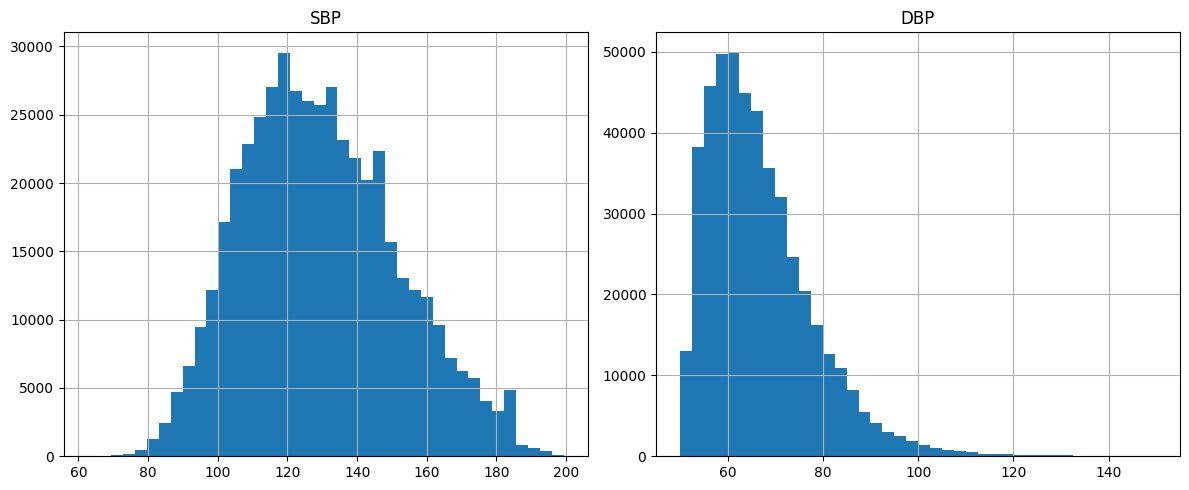

In [22]:
df_train[["SBP", "DBP"]].hist(
    bins=40,
    figsize=(12, 5)
)

plt.tight_layout()
plt.show()

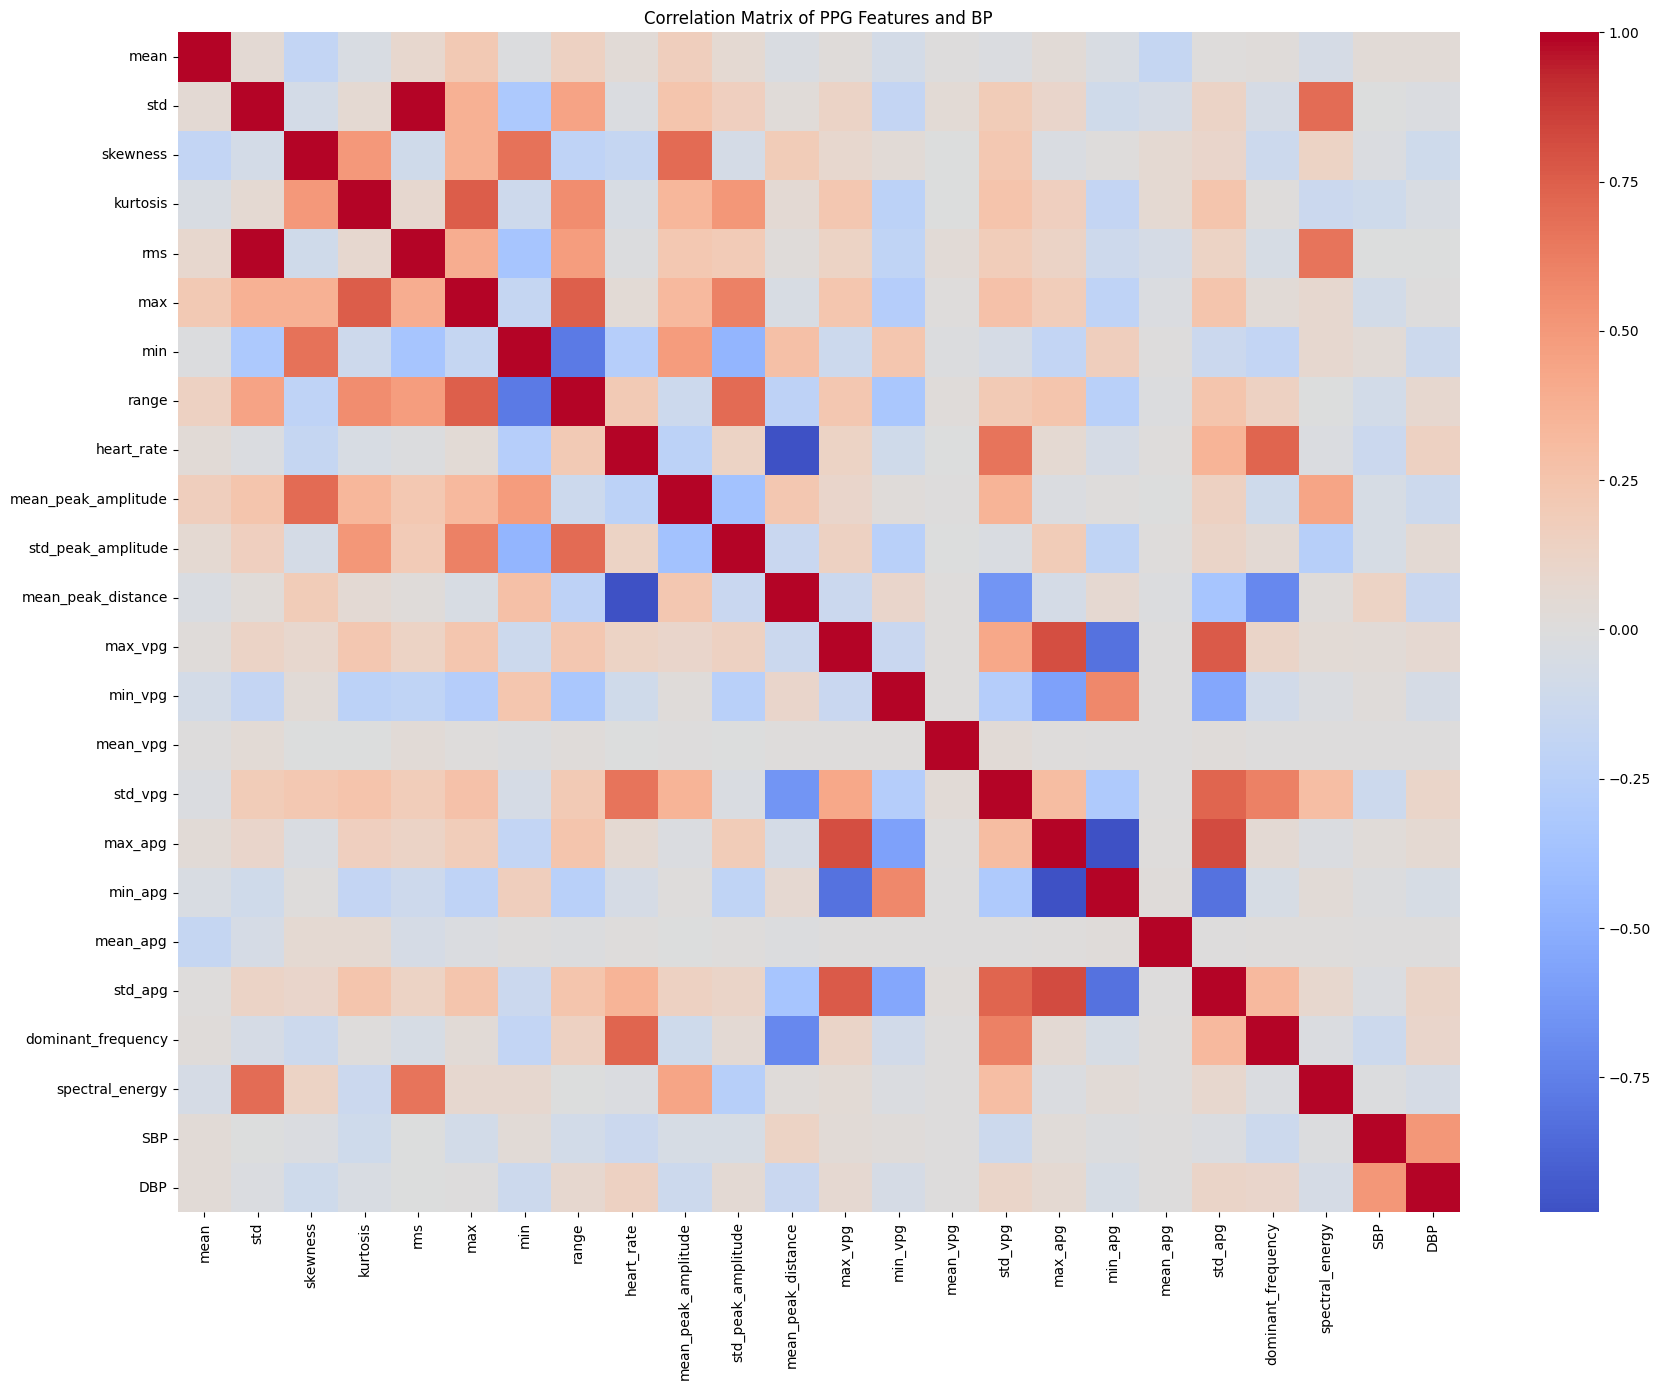

In [23]:
corr = df_train.corr(numeric_only=True)

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of PPG Features and BP")
plt.tight_layout()

plt.show()

In [24]:
bp_corr = corr[["SBP", "DBP"]].sort_values(
    "SBP",
    ascending=False
)

print(bp_corr)

                          SBP       DBP
SBP                  1.000000  0.512675
DBP                  0.512675  1.000000
mean_peak_distance   0.133417 -0.149071
min                  0.041348 -0.122465
mean                 0.032010  0.035543
max_vpg              0.030042  0.067039
max_apg              0.023848  0.059760
min_vpg              0.015423 -0.064118
mean_apg             0.003262  0.002064
mean_vpg             0.000112 -0.000623
rms                 -0.005829 -0.008724
std                 -0.010834 -0.019580
spectral_energy     -0.015741 -0.059048
min_apg             -0.018471 -0.055947
std_apg             -0.021321  0.113968
skewness            -0.021579 -0.106576
mean_peak_amplitude -0.052566 -0.123444
std_peak_amplitude  -0.055103  0.058066
range               -0.081382  0.080702
max                 -0.084359 -0.002252
kurtosis            -0.109582 -0.036044
std_vpg             -0.121897  0.107192
dominant_frequency  -0.122343  0.104056
heart_rate          -0.134617  0.146114


In [25]:
feature_columns = [
    "mean",
    "std",
    "skewness",
    "kurtosis",
    "rms",
    "max",
    "min",
    "range",

    "heart_rate",
    "mean_peak_amplitude",
    "std_peak_amplitude",
    "mean_peak_distance",

    "max_vpg",
    "min_vpg",
    "mean_vpg",
    "std_vpg",

    "max_apg",
    "min_apg",
    "mean_apg",
    "std_apg",

    "dominant_frequency",
    "spectral_energy"
]

X_train = df_train[feature_columns]
X_val = df_val[feature_columns]
X_test = df_test[feature_columns]

y_train_sbp = df_train["SBP"]
y_val_sbp = df_val["SBP"]
y_test_sbp = df_test["SBP"]

y_train_dbp = df_train["DBP"]
y_val_dbp = df_val["DBP"]
y_test_dbp = df_test["DBP"]

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = LinearRegression()

# Train
model.fit(X_train, y_train)
train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
print("Training MAE:", train_mae)
print("Training RMSE:", train_rmse)
# Validation
val_pred = model.predict(X_val)

val_mae = mean_absolute_error(y_val, val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print("Validation MAE:", val_mae)
print("Validation RMSE:", val_rmse)

# Final test
sbp_pred = model.predict(X_test)

Training MAE: 12.74661566624145
Training RMSE: 16.979039684731248
Validation MAE: 12.695637083871787
Validation RMSE: 16.96808185279147


In [32]:
sbp_mae = mean_absolute_error(
    y_test_sbp,
    sbp_pred
)

sbp_rmse = np.sqrt(
    mean_squared_error(
        y_test_sbp,
        sbp_pred
    )
)

sbp_r2 = r2_score(
    y_test_sbp,
    sbp_pred
)

print("SBP MAE :", sbp_mae)
print("SBP RMSE:", sbp_rmse)
print("SBP R²   :", sbp_r2)

SBP MAE : 17.545301305094252
SBP RMSE: 21.81923085279961
SBP R²   : 0.05148535590723491


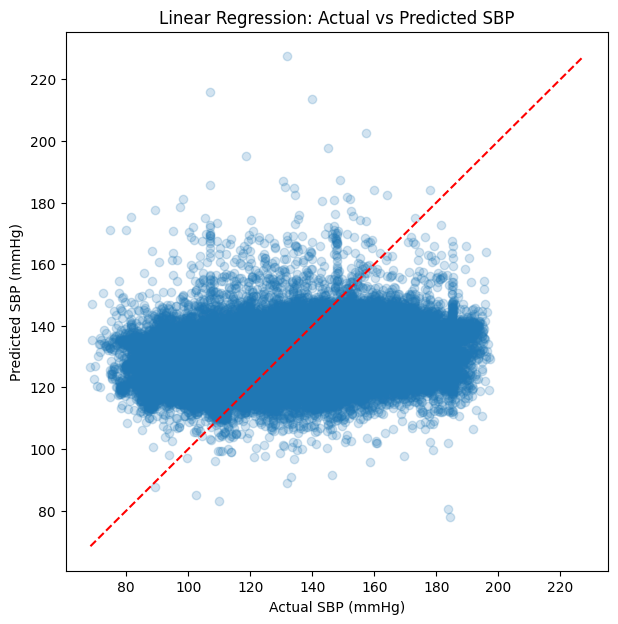

In [30]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_sbp,
    sbp_pred,
    alpha=0.2
)

min_val = min(
    y_test_sbp.min(),
    sbp_pred.min()
)

max_val = max(
    y_test_sbp.max(),
    sbp_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--"
)

plt.xlabel("Actual SBP (mmHg)")
plt.ylabel("Predicted SBP (mmHg)")
plt.title("Linear Regression: Actual vs Predicted SBP")

plt.show()